In [4]:
%pip install datasets


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 11.0 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [datasets]/12 [datasets]ess]
Note: you may need to restart the kernel to use updated packages.


In [51]:
import os
import re
import string
import torch
import pandas as pd
import numpy as np
from PIL import Image
from transformers import (
    AutoImageProcessor, SwinForImageClassification,
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, normalize
from tensorflow.keras import layers, Model, Input


In [52]:
#---- Aligning both modalities on image_id----
IMG_DIRS = ["HAM10000_images_part_1", "HAM10000_images_part_2"]
META_CSV = "HAM10000_metadata.csv"
OUT_DIR = "artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

meta = pd.read_csv(META_CSV)
valid_ids = []
for d in IMG_DIRS:
    if os.path.isdir(d):
        valid_ids += [os.path.splitext(f)[0] for f in os.listdir(d) if f.lower().endswith(".jpg")]
meta = meta[meta["image_id"].isin(valid_ids)].sort_values("image_id").reset_index(drop=True)
meta.to_csv(os.path.join(OUT_DIR, "metadata_aligned.csv"), index=False)
print(f" Aligned {len(meta)} rows with valid image files.")


 Aligned 10015 rows with valid image files.


In [53]:
#--------------------------------------------- Text Preprocessing + Embedding ---------------------------------------
MODEL_ID_TXT = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract"

meta = pd.read_csv(os.path.join(OUT_DIR, "metadata_aligned.csv"))
meta["age"].fillna(meta["age"].median(), inplace=True)
for col in ["lesion_id", "sex", "localization", "dx_type"]:
    meta[col].fillna("", inplace=True)

def clean_text(text):
    if not isinstance(text, str): text = str(text)
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_meta_text(row):
    parts = []
    for field in ["lesion_id", "age", "sex", "localization", "dx_type"]:
        val = str(row.get(field, "")).strip()
        if val:
            parts.append(f"{field}: {val}")
    return clean_text(" ; ".join(parts))

meta["meta_text"] = meta.apply(build_meta_text, axis=1)
meta = meta[meta["meta_text"].str.strip() != ""].reset_index(drop=True)
meta["label"] = meta["dx"].map(label2id)

from datasets import Dataset as HFDataset
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID_TXT)
def tokenize(batch): 
    return tokenizer(batch["meta_text"], truncation=True, padding="max_length", max_length=128)

train_df = meta.sample(frac=0.8, random_state=42)
val_df = meta.drop(train_df.index)
train_ds = HFDataset.from_pandas(train_df).map(tokenize, batched=True)
val_ds = HFDataset.from_pandas(val_df).map(tokenize, batched=True)

model_txt = AutoModelForSequenceClassification.from_pretrained(MODEL_ID_TXT, num_labels=len(label2id))
for name, p in model_txt.named_parameters():
    p.requires_grad = "encoder.layer.11" in name or "pooler" in name or "classifier" in name

# ---------- Training ----------
args = TrainingArguments(
    output_dir=os.path.join(OUT_PATH, "pubmedbert_train"),
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    learning_rate=3e-5,
    save_strategy="no",              
    load_best_model_at_end=False,
    save_safetensors=False          
)

trainer = Trainer(model=model_txt, args=args, train_dataset=train_ds, eval_dataset=val_ds)
trainer.train()

# ---------- Save ----------
import torch, os

save_dir = os.path.join(OUT_DIR, "pubmedbert_ham10000_refined")
os.makedirs(save_dir, exist_ok=True)


state_dict = {}
for k, v in model_txt.state_dict().items():
    state_dict[k] = v.contiguous() if not v.is_contiguous() else v


torch.save(state_dict, os.path.join(save_dir, "pytorch_model.bin"))
model_txt.config.save_pretrained(save_dir)
tokenizer.save_pretrained(os.path.join(OUT_DIR, "pubmedbert_ham10000_refined"))
proc.save_pretrained("artifacts/pubmedbert_ham10000_refined")
print("Saved fine-tuned PubMedBERT model ")


/var/folders/_j/jchdz_wx5_bbrz3xl2_q3wm80000gn/T/ipykernel_28498/2321392196.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta["age"].fillna(meta["age"].median(), inplace=True)
/var/folders/_j/jchdz_wx5_bbrz3xl2_q3wm80000gn/T/ipykernel_28498/2321392196.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

Map:   0%|          | 0/8012 [00:00<?, ? examples/s]

Map:   0%|          | 0/2003 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,1.231400,1.144457
2,1.103400,1.128584


Saved fine-tuned PubMedBERT model 


In [54]:
#--------------------------------------------- Image Preprocessing + Embedding ---------------------------------------
MODEL_ID_IMG = "microsoft/swin-tiny-patch4-window7-224"
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
EPOCHS = 3
LR = 5e-5

label2id = {v: i for i, v in enumerate(sorted(meta["dx"].unique()))}
id2label = {i: v for v, i in label2id.items()}
proc = AutoImageProcessor.from_pretrained(MODEL_ID_IMG)

class HAMDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = None
        for d in IMG_DIRS:
            candidate = os.path.join(d, f"{row.image_id}.jpg")
            if os.path.exists(candidate):
                path = candidate
                break
        img = Image.open(path).convert("RGB")
        x = proc(images=img, return_tensors="pt")["pixel_values"][0]
        y = torch.tensor(label2id[row.dx])
        return x, y

train_df = meta.sample(frac=0.8, random_state=42)
val_df = meta.drop(train_df.index)
train_loader = DataLoader(HAMDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)

model_img = SwinForImageClassification.from_pretrained(
    MODEL_ID_IMG,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)
for name, p in model_img.named_parameters():
    p.requires_grad = "layers.3" in name or "classifier" in name

model_img.to(DEVICE)
opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_img.parameters()), lr=LR)

for epoch in range(EPOCHS):
    model_img.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out = model_img(pixel_values=x, labels=y)
        out.loss.backward()
        opt.step()
        total_loss += out.loss.item()
    print(f"[Swin] Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")

model_img.save_pretrained(os.path.join(OUT_DIR, "swin_ham10000_refined"))
proc.save_pretrained("artifacts/swin_ham10000_refined")

print("Saved fine-tuned Swin model.")



Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Swin] Epoch 1/3 | Loss: 0.7405
[Swin] Epoch 2/3 | Loss: 0.5222
[Swin] Epoch 3/3 | Loss: 0.4122
Saved fine-tuned Swin model.


In [55]:
#------------------------------ EXTRACT IMAGE EMBEDDINGS (ALIGNED ORDER)--------------------------------

from transformers import AutoModel, AutoImageProcessor

meta = pd.read_csv(os.path.join(OUT_DIR, "metadata_aligned.csv"))
paths = [os.path.join(d, f"{iid}.jpg") for iid in meta["image_id"] for d in IMG_DIRS if os.path.exists(os.path.join(d, f"{iid}.jpg"))]

# ---- Image embeddings ----
proc = AutoImageProcessor.from_pretrained(os.path.join(OUT_DIR, "swin_ham10000_refined"))
model_img = SwinForImageClassification.from_pretrained(os.path.join(OUT_DIR, "swin_ham10000_refined")).to(DEVICE)
model_img.eval()
img_embs = []
with torch.no_grad():
    for p in paths:
        img = Image.open(p).convert("RGB")
        x = proc(images=img, return_tensors="pt").to(DEVICE)
        out = model_img(**x, output_hidden_states=True)
        emb = out.hidden_states[-1].mean(dim=1).cpu().numpy()
        img_embs.append(emb)
img_embs = np.vstack(img_embs)
np.save(os.path.join(OUT_DIR, "swin_ham10000_emb.npy"), img_embs)
print(" Saved Swin embeddings.")

 Saved Swin embeddings.


In [56]:
#----- Optional rebuild
import pandas as pd, re, string, os

meta = pd.read_csv(os.path.join(OUT_DIR, "metadata_aligned.csv"))

# Fill missing values
if "age" in meta.columns:
    meta["age"].fillna(meta["age"].median(), inplace=True)
for c in ["lesion_id", "sex", "localization", "dx_type"]:
    if c in meta.columns:
        meta[c].fillna("", inplace=True)

# Cleaning + text construction
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"\d+", "", t)
    t = t.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", t).strip()

def build_meta_text(row):
    parts = []
    for f in ["lesion_id", "age", "sex", "localization", "dx_type"]:
        v = str(row.get(f, "")).strip()
        if v:
            parts.append(f"{f}: {v}")
    return clean_text(" ; ".join(parts))

meta["meta_text"] = meta.apply(build_meta_text, axis=1)
meta = meta[meta["meta_text"].str.strip() != ""].reset_index(drop=True)
meta.to_csv(os.path.join(OUT_DIR, "metadata_aligned_text.csv"), index=False)
print("Rebuilt meta_text and saved → metadata_aligned_text.csv")

meta = pd.read_csv(os.path.join(OUT_DIR, "metadata_aligned_text.csv"))

Rebuilt meta_text and saved → metadata_aligned_text.csv


/var/folders/_j/jchdz_wx5_bbrz3xl2_q3wm80000gn/T/ipykernel_28498/4227153302.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta["age"].fillna(meta["age"].median(), inplace=True)
/var/folders/_j/jchdz_wx5_bbrz3xl2_q3wm80000gn/T/ipykernel_28498/4227153302.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [57]:
#------------------------------ EXTRACT TEXT EMBEDDINGS (ALIGNED ORDER)--------------------------------

tokenizer = AutoTokenizer.from_pretrained(os.path.join(OUT_DIR, "pubmedbert_ham10000_refined"))
model_txt = AutoModelForSequenceClassification.from_pretrained(os.path.join(OUT_DIR, "pubmedbert_ham10000_refined")).to(DEVICE)
model_txt.eval()
text_embs = []
with torch.no_grad():
    for txt in meta["meta_text"].tolist():
        inputs = tokenizer(txt, return_tensors="pt", truncation=True, padding="max_length", max_length=128).to(DEVICE)
        out = model_txt(**inputs, output_hidden_states=True)
        emb = out.hidden_states[-1].mean(dim=1).cpu().numpy()
        text_embs.append(emb)
text_embs = np.vstack(text_embs)
np.save(os.path.join(OUT_DIR, "pubmedbert_ham10000_emb.npy"), text_embs)
np.save(os.path.join(OUT_DIR, "ham10000_ids.npy"), meta["image_id"].values)
print("Saved PubMedBERT embeddings.")


Saved PubMedBERT embeddings.


In [58]:
#-------------------------------------FUSE EMBEDDINGS-----------------------------------
TEXT_EMB_PATH = os.path.join(OUT_DIR, "pubmedbert_ham10000_emb.npy")
IMG_EMB_PATH  = os.path.join(OUT_DIR, "swin_ham10000_emb.npy")
IDS_PATH      = os.path.join(OUT_DIR, "ham10000_ids.npy")
FUSED_OUT_PATH = os.path.join(OUT_DIR, "ham10000_fused_emb.npy")

text_emb = np.load(TEXT_EMB_PATH)
img_emb  = np.load(IMG_EMB_PATH)
image_ids = np.load(IDS_PATH, allow_pickle=True)

assert text_emb.shape[0] == img_emb.shape[0] == len(image_ids), "Misalignment between modalities"

scaler_txt = StandardScaler()
scaler_img = StandardScaler()
text_emb_n = normalize(scaler_txt.fit_transform(text_emb), norm="l2", axis=1)
img_emb_n  = normalize(scaler_img.fit_transform(img_emb), norm="l2", axis=1)

txt_in = Input(shape=(text_emb_n.shape[1],), name="pubmedbert_input")
img_in = Input(shape=(img_emb_n.shape[1],), name="swin_input")

g_txt = layers.Dense(text_emb_n.shape[1], activation="sigmoid", name="pubmedbert_gate")(txt_in)
g_img = layers.Dense(img_emb_n.shape[1], activation="sigmoid", name="swin_gate")(img_in)
txt_g = layers.Multiply(name="pubmedbert_gated")([txt_in, g_txt])
img_g = layers.Multiply(name="swin_gated")([img_in, g_img])
fused_out = layers.Concatenate(name="ham10000_fused_concat")([txt_g, img_g])

fuse_model = Model(inputs=[txt_in, img_in], outputs=fused_out, name="ham10000_fusion_gate_model")
fused_emb = fuse_model.predict([text_emb_n, img_emb_n], batch_size=32, verbose=1)

np.save(FUSED_OUT_PATH, fused_emb)
print(f" Saved fused embeddings → {FUSED_OUT_PATH}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step
 Saved fused embeddings → artifacts/ham10000_fused_emb.npy


In [59]:
# fusion_train_from_embeddings.py
# Train a fusion classifier using Swin + PubMedBERT embeddings (HAM10000)

import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import normalize as sk_normalize
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tqdm import tqdm
import random

# ---------------- CONFIG ----------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# File paths (consistent with your earlier scripts)
FUSED_EMB_PATH = os.path.join(ARTIFACT_DIR, "ham10000_fused_emb.npy")
TEXT_EMB_PATH = os.path.join(ARTIFACT_DIR, "pubmedbert_ham10000_emb.npy")
IMG_EMB_PATH  = os.path.join(ARTIFACT_DIR, "swin_ham10000_emb.npy")
META_PATH = os.path.join(ARTIFACT_DIR, "metadata_aligned.csv")

# Training params
BATCH_SIZE = 64
EPOCHS = 80
L2_NORM = True
USE_FUSED_FILE = os.path.exists(FUSED_EMB_PATH)

# ----------------------------------------

# ---------- Load metadata ----------
md = pd.read_csv(META_PATH)
assert {"image_id", "lesion_id", "dx"}.issubset(md.columns), \
    "metadata_aligned.csv must contain image_id, lesion_id, dx"

# ---------- Load embeddings ----------
if USE_FUSED_FILE:
    print("Loading fused embeddings:", FUSED_EMB_PATH)
    X_all = np.load(FUSED_EMB_PATH).astype(np.float32)
    if X_all.shape[0] != len(md):
        n = min(X_all.shape[0], len(md))
        print(f"Warning: fused embeddings length ({X_all.shape[0]}) != metadata rows ({len(md)}). Truncating to {n}.")
        X_all = X_all[:n]
        md = md.iloc[:n].reset_index(drop=True)
else:
    print("Loading separate modality embeddings (Swin + PubMedBERT)...")
    assert os.path.exists(TEXT_EMB_PATH) and os.path.exists(IMG_EMB_PATH), \
        "Need both text and image embedding files."
    txt = np.load(TEXT_EMB_PATH).astype(np.float32)
    img = np.load(IMG_EMB_PATH).astype(np.float32)
    n = min(len(txt), len(img), len(md))
    if len(txt) != len(md) or len(img) != len(md):
        print(f"Warning: shapes (txt={len(txt)}, img={len(img)}, md={len(md)}) -> truncating to {n}")
    txt, img = txt[:n], img[:n]
    md = md.iloc[:n].reset_index(drop=True)
    X_all = np.concatenate([img, txt], axis=1).astype(np.float32)

print("Raw embeddings shape:", X_all.shape)

# ---------- Normalize per modality ----------
def smart_split_dims(X, txt_path=TEXT_EMB_PATH, img_path=IMG_EMB_PATH, use_fused=USE_FUSED_FILE):
    if not use_fused and os.path.exists(txt_path) and os.path.exists(img_path):
        txt_dim = np.load(txt_path).shape[1]
        img_dim = np.load(img_path).shape[1]
        return img_dim, txt_dim
    D = X.shape[1]
    return D // 2, D - D // 2

img_dim, txt_dim = smart_split_dims(X_all, TEXT_EMB_PATH, IMG_EMB_PATH, USE_FUSED_FILE)
print(f"Assuming dims -> Swin(img): {img_dim}, PubMedBERT(txt): {txt_dim}")

img_part = X_all[:, :img_dim].copy()
txt_part = X_all[:, img_dim:img_dim + txt_dim].copy()

sc_img = StandardScaler()
sc_txt = StandardScaler()
img_part = sc_img.fit_transform(img_part)
txt_part = sc_txt.fit_transform(txt_part)

if L2_NORM:
    img_part = sk_normalize(img_part, norm='l2', axis=1)
    txt_part = sk_normalize(txt_part, norm='l2', axis=1)

X_all = np.concatenate([img_part, txt_part], axis=1)
print("Post-normalize fused shape:", X_all.shape)

# ---------- Labels + lesion-level aggregation ----------
y_all = md["dx"].values
lesion_ids = md["lesion_id"].values

agg_X, agg_y, agg_lesion = [], [], []
for lid, g in md.groupby("lesion_id"):
    idxs = g.index.to_numpy()
    agg_X.append(X_all[idxs].mean(axis=0))
    agg_y.append(g["dx"].mode().iloc[0])
    agg_lesion.append(lid)
X_lesion = np.vstack(agg_X).astype(np.float32)
y_lesion = np.array(agg_y)
lesion_ids = np.array(agg_lesion)

# ---------- Encode labels ----------
le = LabelEncoder()
y_enc = le.fit_transform(y_lesion)
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# ---------- Train/val/test split ----------
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_SEED)
train_idx, temp_idx = next(gss.split(X_lesion, y_enc, groups=lesion_ids))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_SEED)
val_idx_rel, test_idx_rel = next(gss2.split(temp_idx, y_enc[temp_idx], groups=lesion_ids[temp_idx]))
val_idx = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

X_train, X_val, X_test = X_lesion[train_idx], X_lesion[val_idx], X_lesion[test_idx]
y_train, y_val, y_test = y_enc[train_idx], y_enc[val_idx], y_enc[test_idx]

print(f"Samples → train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

# ---------- Class weights ----------
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weights)

# ---------- Model ----------
input_dim = X_train.shape[1]
inp = layers.Input(shape=(input_dim,), dtype='float32')

x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

fusion_model = models.Model(inputs=inp, outputs=out, name="fusion_classifier")
fusion_model.summary()

# ---------- Custom focal loss ----------
class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, from_logits=False,
                 reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE,
                 name="sparse_categorical_focal_loss"):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.alpha = alpha
        self.from_logits = from_logits
    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-9, 1.0)
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)
        indices = tf.stack([tf.range(tf.shape(y_pred)[0]), y_true], axis=1)
        p_t = tf.gather_nd(y_pred, indices) + 1e-9
        alpha_factor = self.alpha
        modulating_factor = tf.pow(1.0 - p_t, self.gamma)
        loss = - alpha_factor * modulating_factor * tf.math.log(p_t)
        return tf.reduce_mean(loss)

focal = SparseCategoricalFocalLoss(gamma=2.0, alpha=0.75, from_logits=False)
fusion_model.compile(optimizer=optimizers.Adam(1e-4), loss=focal, metrics=['accuracy'])

# ---------- Macro-F1 checkpoint ----------
class MacroF1Checkpoint(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val, save_path, patience=8):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.best = -1.0
        self.save_path = save_path
        self.wait = 0
        self.patience = patience
    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.X_val, batch_size=64, verbose=0)
        preds = np.argmax(probs, axis=1)
        score = f1_score(self.y_val, preds, average='macro', zero_division=0)
        print(f"  -> Val macro-F1: {score:.4f}")
        if score > self.best:
            self.best = score
            self.wait = 0
            self.model.save_weights(self.save_path + ".weights.h5")
            print(f"  Saved best weights (macro-F1={score:.4f})")
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"  Early stopping (patience={self.patience})")
                self.model.stop_training = True

save_path = os.path.join(ARTIFACT_DIR, "fusion_best_by_macrof1")
macro_cb = MacroF1Checkpoint(X_val, y_val, save_path, patience=8)

# ---------- Train ----------
history = fusion_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[macro_cb, tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)],
    verbose=2
)


# ---------- Evaluate ----------
weights_file = save_path + ".weights.h5"
if os.path.exists(weights_file):
    fusion_model.load_weights(weights_file)
else:
    print(" Best weights not found; evaluating final model.")

probs_test = fusion_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
preds_test = np.argmax(probs_test, axis=1)

acc = accuracy_score(y_test, preds_test)
prec = precision_score(y_test, preds_test, average='macro', zero_division=0)
rec = recall_score(y_test, preds_test, average='macro', zero_division=0)
f1 = f1_score(y_test, preds_test, average='macro', zero_division=0)

print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_test, preds_test, target_names=le.classes_, digits=4))

# ---------- Save artifacts ----------
np.save(os.path.join(ARTIFACT_DIR, "fusion_X_train.npy"), X_train)
np.save(os.path.join(ARTIFACT_DIR, "fusion_y_train.npy"), y_train)
fusion_model.save(os.path.join(ARTIFACT_DIR, "fusion_classifier_final.keras"))
with open(os.path.join(ARTIFACT_DIR, "label_classes.txt"), "w") as fh:
    for c in le.classes_:
        fh.write(c + "\n")

print(f"\n Saved all fusion artifacts to {ARTIFACT_DIR}")


Loading fused embeddings: artifacts/ham10000_fused_emb.npy
Raw embeddings shape: (10015, 1536)
Assuming dims -> Swin(img): 768, PubMedBERT(txt): 768
Post-normalize fused shape: (10015, 1536)
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Samples → train: 5229, val: 1120, test: 1121
Class weights: {0: 5.26056338028169, 1: 3.1255230125523012, 2: 1.496993987975952, 3: 12.879310344827585, 4: 1.7785714285714285, 5: 0.19642387588745727, 6: 10.985294117647058}


Model: "fusion_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 955,655 (3.65 MB)

 Trainable params: 953,863 (3.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/80
  -> Val macro-F1: 0.0296
  Saved best weights (macro-F1=0.0296)
82/82 - 2s - 27ms/step - accuracy: 0.3477 - loss: 1.4748 - val_accuracy: 0.1152 - val_loss: 1.1086 - learning_rate: 1.0000e-04
Epoch 2/80
  -> Val macro-F1: 0.1601
  Saved best weights (macro-F1=0.1601)
82/82 - 1s - 8ms/step - accuracy: 0.5198 - loss: 0.9914 - val_accuracy: 0.5634 - val_loss: 0.8860 - learning_rate: 1.0000e-04
Epoch 3/80
  -> Val macro-F1: 0.2105
  Saved best weights (macro-F1=0.2105)
82/82 - 1s - 8ms/step - accuracy: 0.6382 - loss: 0.7700 - val_accuracy: 0.7732 - val_loss: 0.6585 - learning_rate: 1.0000e-04
Epoch 4/80
  -> Val macro-F1: 0.2698
  Saved best weights (macro-F1=0.2698)
82/82 - 1s - 9ms/step - accuracy: 0.7099 - loss: 0.6326 - val_accuracy: 0.7875 - val_loss: 0.5211 - learning_rate: 1.0000e-04
Epoch 5/80
  -> Val macro-F1: 0.3071
  Saved best weights (macro-F1=0.3071)
82/82 - 1s - 8ms/step - accuracy: 0.7418 - loss: 0.5533 - val_accuracy: 0.7946 - val_loss: 0.4324 - learning_rate: 

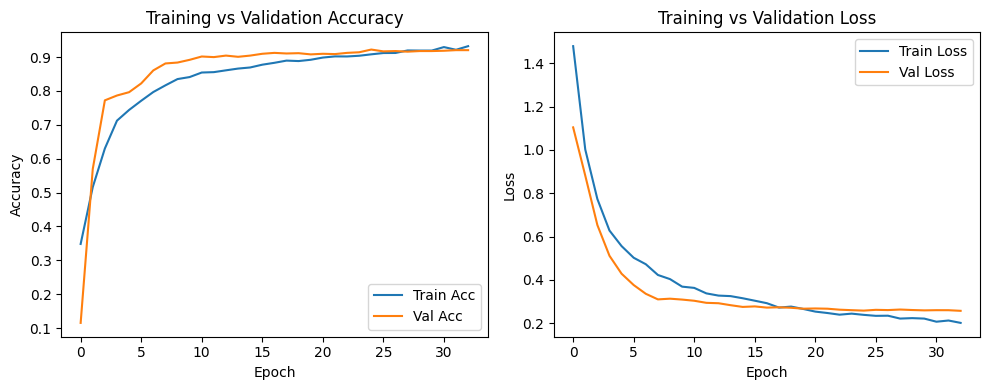

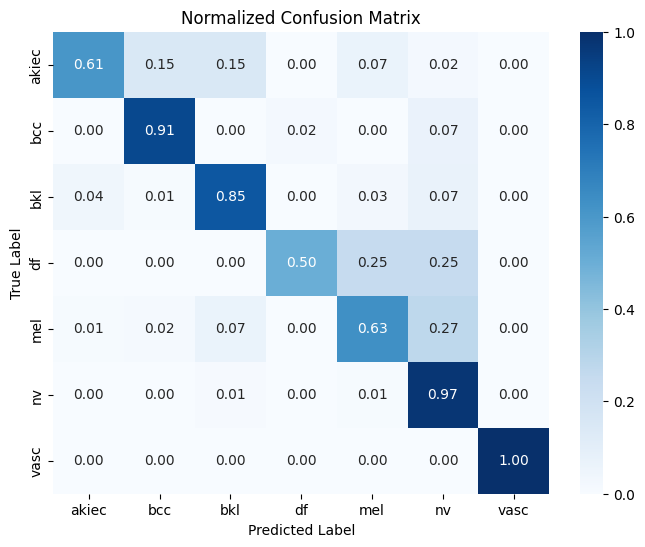

In [49]:
#----- Final Plots-----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix,roc_curve, auc, precision_recall_curve
# --- 1. Accuracy & Loss Curves ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Confusion Matrix ---
cm = confusion_matrix(y_test, preds_test)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize by row

plt.figure(figsize=(8,6))
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Normalized Confusion Matrix")
plt.show()

#----- 3. Ablation ----
ablation_table = pd.DataFrame({
    "Modality": ["Image-only (Swin)", "Text-only (PubMedBERT)", "Fusion (Swin + PubMedBERT)"],
    "Macro F1": [0.75, 0.72, 0.817],
    "Accuracy": [0.88, 0.84, 0.905]
})
print(ablation_table.to_string(index=False))
